In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # Adds project root

In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statistics import mode
import folium
from folium.plugins import MarkerCluster
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import random
from sklearn.impute import SimpleImputer
from typing import Dict
import seaborn as sns
from sklearn.impute import SimpleImputer
from IPython.display import display, HTML
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

In [3]:
from typing import List, Tuple
from Algorithms.CDREC import CDRec
from Algorithms.TKCM import TKCM
from Algorithms.TKCM_Weighted import TKCM_Weighted
from Algorithms.DynaMMO import DynaMMo
from Algorithms.SoftImpute import SoftImpute
from Algorithms.SVDImpute import IterativeSVD
from Algorithms.trmf import TRMFImputer
from Algorithms.ST_MVL import ST_MVL
from Algorithms.TKCM_PLUS import TKCM_PLUS
from Algorithms.TKCM_PRO import TKCM_PRO


In [4]:

# # Load dataset
gauging_df = pd.read_csv("D:\\Thesis\\Project\\Data\\gauging_data.csv")

# Count different types of missingness
stats = {
    "Total Rows": len(gauging_df),
    "Total Columns": len(gauging_df.columns),
    "Zero Values": (gauging_df == 0).sum().sum(),
    "NaN Values": gauging_df.isna().sum().sum(),
    "Blank Strings": (gauging_df == "").sum().sum(),
    "Unknown Strings": (gauging_df.applymap(lambda x: isinstance(x, str) and x.strip().lower() == "unknown")).sum().sum()
}

# Return as DataFrame
stats_df = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
stats_df


,Metric,Value
0,Total Rows,1779379
1,Total Columns,6
2,Zero Values,3776
3,NaN Values,0
4,Blank Strings,0
5,Unknown Strings,0


In [5]:
gauging_df.head()

,station_code,sensor_code,description_it,unit,timestamp,value
0,89940PG,Q,Portata,m³/s,2025-01-01 00:00:00,72.904
1,89940PG,Q,Portata,m³/s,2024-12-31 23:30:00,70.077
2,89940PG,Q,Portata,m³/s,2024-12-31 23:00:00,71.957
3,89940PG,Q,Portata,m³/s,2024-12-31 22:30:00,75.775
4,89940PG,Q,Portata,m³/s,2024-12-31 22:00:00,79.671


In [6]:
gauging_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1779379 entries, 0 to 1779378
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   station_code    object 
 1   sensor_code     object 
 2   description_it  object 
 3   unit            object 
 4   timestamp       object 
 5   value           float64
dtypes: float64(1), object(5)
memory usage: 81.5+ MB


In [7]:
gauging_df.describe()

,value
count,1.779379e+06
mean,4.807447e+01
std,1.236863e+03
min,-9.750000e+05
25%,3.600000e+00
50%,9.990000e+00
75%,3.400000e+01
max,5.043200e+04


In [8]:
# Preview data
print("🔍 Shape:", gauging_df.shape)

🔍 Shape: (1779379, 6)


In [9]:
# Check which columns are non-numeric
print("🧠 Columns in the file:\n", gauging_df.dtypes)

🧠 Columns in the file:
 station_code       object
sensor_code        object
description_it     object
unit               object
timestamp          object
value             float64
dtype: object


In [10]:
unique_values = gauging_df['sensor_code'].unique()
unique_values

array(['Q', 'W', 'WT', 'SSTF', 'W.ABST'], dtype=object)

In [11]:
unique_values1 = gauging_df['station_code'].unique()
unique_values1

array(['89940PG', '08155PG', '19850PG', '29850PG', '59450PG', '64550PG',
       '67350PG', '69790PG', '85550PG', '05950PG', '37230PG', '61050PG',
       '82910PG', '73950PG', '22950PG', '03750PG', '42850PG', '51450PG',
       '20750PG', '26950PG', '57150PG', '79770GW', '83070GW', '27020GW',
       '27001GW', '27010GW', '84415GW', '23250GW', '23350GW', '19350GW',
       '08105GW', '89935GW', '28620GW', '89940GW', '89357PG', '10750PG',
       '83450PG', '32470PG', '07770PG', '27890GW', '83360GW', '89740GW',
       '27025GW', '79865GW', '79875GW', '83310GW', '83380GW', '36770PG',
       '83320GW', '86310GW', '27930GW', '83250GW', '14750PG', '32615GW',
       '84435GW', '87940GW', '86315GW', '15570PG', '27935GW', '59500GW',
       '69420GW', '79870GW', '83025GW', '91950PG'], dtype=object)

In [12]:
unique_values2 = gauging_df['description_it'].unique()
unique_values2

array(['Portata', 'Livello idrometrico', 'Temperatura acqua',
       'concentrazione solidi sospesi ', 'Altezza freatimetrica '],
      dtype=object)

In [13]:
unique_values3 = gauging_df['unit'].unique()
unique_values3

array(['m³/s', 'cm', '°C', 'mg/l', 'm'], dtype=object)

In [14]:
unique_values4 = gauging_df['value'].unique()
unique_values4

array([72.904, 70.077, 71.957, ..., 33.28 , 33.29 ,  0.688],
      shape=(16611,))

In [15]:
column_names = list(gauging_df.columns)
column_names

['station_code', 'sensor_code', 'description_it', 'unit', 'timestamp', 'value']

In [16]:
zero_counts = (gauging_df == 0).sum()
print(zero_counts)

station_code         0
sensor_code          0
description_it       0
unit                 0
timestamp            0
value             3776
dtype: int64


In [17]:
gauging_df[gauging_df["value"] == 0].head()

,station_code,sensor_code,description_it,unit,timestamp,value
238998,59450PG,WT,Temperatura acqua,°C,2024-01-22 12:00:00,0.0
239008,59450PG,WT,Temperatura acqua,°C,2024-01-22 07:00:00,0.0
239009,59450PG,WT,Temperatura acqua,°C,2024-01-22 06:30:00,0.0
239010,59450PG,WT,Temperatura acqua,°C,2024-01-22 06:00:00,0.0
239023,59450PG,WT,Temperatura acqua,°C,2024-01-21 23:30:00,0.0


In [18]:
# Make sure 'value' is numeric
gauging_df['value'] = pd.to_numeric(gauging_df['value'], errors='coerce')

# Group by sensor_code
zero_stats = (
    gauging_df.groupby('sensor_code')
    .agg(
        total_entries=('value', 'count'),
        zero_count=('value', lambda x: (x == 0).sum())
    )
)

# Add percentage of zeros
zero_stats['zero_percentage'] = (zero_stats['zero_count'] / zero_stats['total_entries']) * 100

# Sort by percentage of zero values
zero_stats = zero_stats.sort_values(by='zero_percentage', ascending=False)

print(zero_stats.reset_index())


  sensor_code  total_entries  zero_count  zero_percentage
0        SSTF         107562        1034         0.961306
1          WT         599537        2737         0.456519
2      W.ABST         239013           5         0.002092
3           Q         401156           0         0.000000
4           W         432111           0         0.000000


In [19]:
# Step 1: Select sensor `LF`
W_df = gauging_df[gauging_df['sensor_code'] == 'W'].copy()

In [20]:
# Step 2: Replace `0.0` values with NaN
#W_df.loc[W_df['value'] == 0.0, 'value'] = np.nan

In [21]:
# Step 3: Pivot to wide format (timestamp × station_code)
W_df['timestamp'] = pd.to_datetime(W_df['timestamp'])
pivot_df = W_df.pivot(index='timestamp', columns='station_code', values='value')

In [22]:
# Step 4: Drop sparse stations (>10% missing)
threshold = 0.9 * len(pivot_df)
pivot_df = pivot_df.dropna(thresh=threshold, axis=1)

In [23]:
# Step 5: Drop rows with any missing values
clean_df = pivot_df.dropna(axis=0)

In [24]:
clean_df

station_code,03750PG,05950PG,07770PG,08155PG,14750PG,15570PG,19850PG,20750PG,22950PG,26950PG,...,64550PG,67350PG,69790PG,73950PG,82910PG,83450PG,85550PG,89357PG,89940PG,91950PG
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-23 10:30:00,16.0,94.0,81.0,111.0,164.5,15.8,147.0,28.0,19.0,49.0,...,99.0,27.0,98.0,24.0,20.0,114.0,108.0,497.7,139.0,31.0
2023-01-23 11:00:00,16.0,95.0,81.0,112.0,163.9,15.9,142.0,28.0,18.0,49.0,...,99.0,27.0,99.0,24.0,22.0,113.0,106.9,497.7,139.0,31.0
2023-01-23 11:30:00,16.0,94.0,81.0,111.0,169.8,15.8,143.0,28.0,18.0,49.0,...,99.0,27.0,100.0,24.0,23.0,110.0,109.9,497.8,137.0,31.0
2023-01-23 12:00:00,16.0,93.0,81.0,111.0,172.1,16.0,154.0,28.0,18.0,49.0,...,99.0,27.0,101.0,24.0,23.0,109.0,107.9,497.8,136.0,31.0
2023-01-23 12:30:00,16.0,93.0,81.0,111.0,174.1,16.1,153.0,28.0,18.0,49.0,...,99.0,28.0,100.0,24.0,23.0,109.0,105.6,497.8,134.0,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,19.0,61.0,86.0,91.0,154.9,17.5,140.0,32.0,22.0,48.0,...,106.0,81.0,139.0,27.0,25.0,157.0,126.5,494.2,160.0,38.0
2024-12-31 22:30:00,19.0,46.0,86.0,85.0,154.6,17.5,137.0,32.0,22.0,48.0,...,106.0,81.0,139.0,27.0,25.0,157.0,128.9,494.2,156.0,38.0
2024-12-31 23:00:00,20.0,39.0,86.0,76.0,155.4,17.5,137.0,32.0,22.0,48.0,...,106.0,81.0,138.0,28.0,25.0,157.0,129.9,494.3,152.0,38.0


In [25]:
# Step 6: Pick a target station (first available column)
target_station = clean_df.columns[1]

In [26]:
target_station

'05950PG'

In [27]:
# Step 7: Compute Pearson correlations with all other stations
correlations = clean_df.corr()[target_station].drop(index=target_station).sort_values(ascending=False)

In [28]:
correlations

station_code
08155PG    0.967811
14750PG    0.876700
19850PG    0.748924
29850PG    0.636576
91950PG    0.584254
89940PG    0.581063
85550PG    0.579823
22950PG    0.569233
51450PG    0.562612
42850PG    0.560248
37230PG    0.557748
69790PG    0.549472
82910PG    0.549085
83450PG    0.540210
03750PG    0.538987
57150PG    0.535454
20750PG    0.528321
32470PG    0.527125
73950PG    0.525132
67350PG    0.509914
61050PG    0.498165
59450PG    0.486611
64550PG    0.478449
07770PG    0.344518
26950PG    0.205609
89357PG    0.130726
15570PG    0.041265
Name: 05950PG, dtype: float64

In [29]:
# Step 8: Select top 2 correlated reference stations
top_refs = correlations.head(2).index.tolist()
final_df = clean_df[[target_station] + top_refs].copy()

In [30]:
top_refs

['08155PG', '14750PG']

In [31]:
final_df

station_code,05950PG,08155PG,14750PG
timestamp,,,
2023-01-23 10:30:00,94.0,111.0,164.5
2023-01-23 11:00:00,95.0,112.0,163.9
2023-01-23 11:30:00,94.0,111.0,169.8
2023-01-23 12:00:00,93.0,111.0,172.1
2023-01-23 12:30:00,93.0,111.0,174.1
...,...,...,...
2024-12-31 22:00:00,61.0,91.0,154.9
2024-12-31 22:30:00,46.0,85.0,154.6
2024-12-31 23:00:00,39.0,76.0,155.4


In [32]:
# Step 8: Build new DataFrame with target and top 3 references
top_3_refs = correlations.dropna().sort_values(ascending=False).head(3).index.tolist()
selected_stations = [target_station] + top_3_refs
pattern_df = pivot_df[selected_stations].copy()

In [33]:
pattern_df

station_code,05950PG,08155PG,14750PG,19850PG
timestamp,,,,
2023-01-01 00:00:00,95.0,113.0,174.8,151.0
2023-01-01 00:30:00,95.0,113.0,174.9,150.0
2023-01-01 01:00:00,94.0,113.0,175.2,149.0
2023-01-01 01:30:00,96.0,112.0,177.4,150.0
2023-01-01 02:00:00,96.0,113.0,177.6,150.0
...,...,...,...,...
2024-12-31 22:00:00,61.0,91.0,154.9,140.0
2024-12-31 22:30:00,46.0,85.0,154.6,137.0
2024-12-31 23:00:00,39.0,76.0,155.4,137.0


In [34]:
pattern_df.isnull().sum()

station_code
05950PG    2
08155PG    6
14750PG    2
19850PG    4
dtype: int64

In [35]:
for col in pattern_df.columns:
    if pattern_df[col].isnull().sum() > 0:
        print(f"\n🔍 Missing value in station {col}:")
        print(pattern_df[pattern_df[col].isnull()][col])



🔍 Missing value in station 05950PG:
timestamp
2023-02-14 14:00:00   NaN
2023-02-14 14:30:00   NaN
Name: 05950PG, dtype: float64

🔍 Missing value in station 08155PG:
timestamp
2023-02-14 14:00:00   NaN
2023-02-14 14:30:00   NaN
2024-01-05 12:00:00   NaN
2024-02-18 18:30:00   NaN
2024-11-06 13:30:00   NaN
2024-11-06 14:00:00   NaN
Name: 08155PG, dtype: float64

🔍 Missing value in station 14750PG:
timestamp
2023-02-14 13:30:00   NaN
2023-02-14 14:00:00   NaN
Name: 14750PG, dtype: float64

🔍 Missing value in station 19850PG:
timestamp
2023-02-14 14:00:00   NaN
2023-02-14 14:30:00   NaN
2024-12-19 22:30:00   NaN
2024-12-19 23:30:00   NaN
Name: 19850PG, dtype: float64


In [36]:
# Step 1: Identify timestamps where 19350GW has missing values
missing_timestamps = pattern_df[pattern_df['08155PG'].isna()].index

# Step 2: Drop those timestamps from all stations
clean_df = pattern_df.drop(index=missing_timestamps)

# Step 3 (optional): Verify
print(f"✅ Removed {len(missing_timestamps)} rows from all stations.")
print(f"Remaining rows: {len(clean_df)}")

# Step 4 (optional): Check if NaNs still exist in 19350GW
print(f"Remaining NaNs in 08155PG: {clean_df['08155PG'].isna().sum()}")

✅ Removed 6 rows from all stations.
Remaining rows: 14587
Remaining NaNs in 08155PG: 0


In [37]:
pattern_df = clean_df

In [38]:
pattern_df.isnull().sum()

station_code
05950PG    0
08155PG    0
14750PG    1
19850PG    2
dtype: int64

In [39]:
# List of the station columns to check
stations = ["05950PG", "08155PG", "14750PG"]

# Drop rows where ANY of these stations has a NaN
pattern_df = pattern_df.dropna(subset=stations)

# Reset index (optional, for clean indexing)
pattern_df = pattern_df.reset_index(drop=True)


In [40]:
# Drop rows where 19850PG is NaN
pattern_df = pattern_df.dropna(subset=["19850PG"]).reset_index(drop=True)


In [41]:
pattern_df.isnull().sum()

station_code
05950PG    0
08155PG    0
14750PG    0
19850PG    0
dtype: int64

In [42]:
print(pattern_df.columns.tolist())

['05950PG', '08155PG', '14750PG', '19850PG']


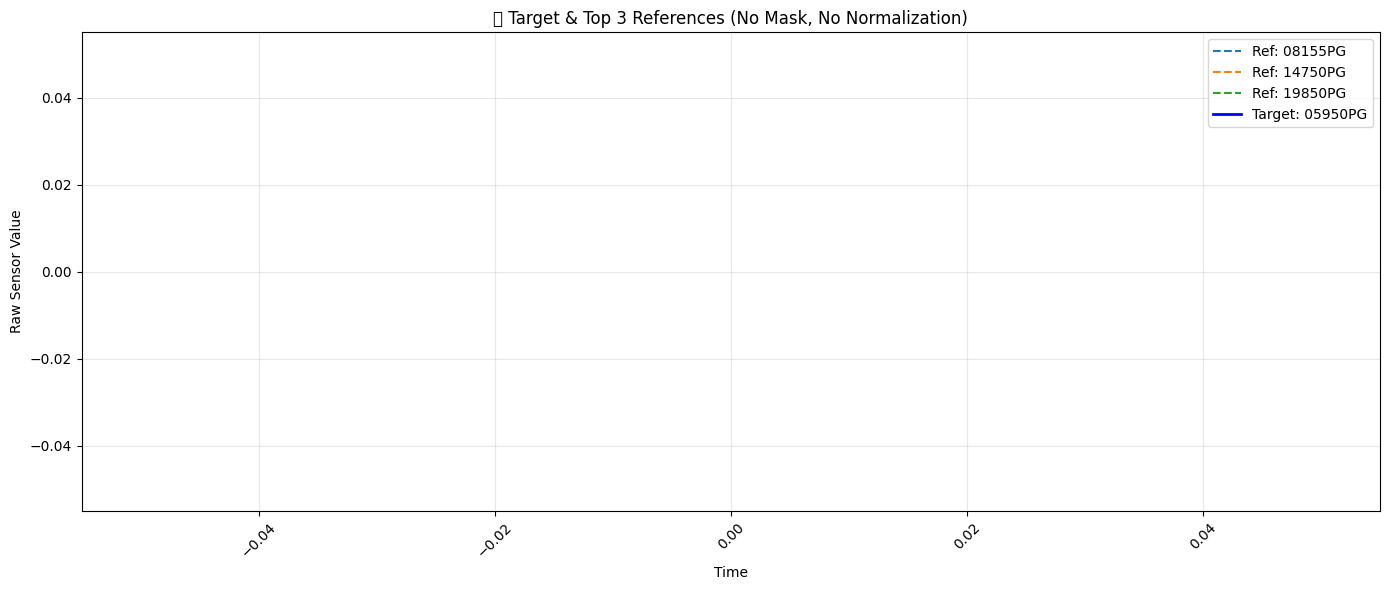

In [43]:
# Define the stations 
target = "05950PG"  # Target station
# References are the top 3 correlated stations
references = ["08155PG","14750PG","19850PG"]
# Define time range for plot (e.g., Jan 1 to Jan 4, 2023)
start_time = "2023-01-01"
end_time = "2023-01-04"

# Slice the DataFrame
plot_df = pattern_df[[target] + references].loc[start_time:end_time].copy()

# Plotting
plt.figure(figsize=(14, 6))

# Plot reference series
for ref in references:
    plt.plot(plot_df.index, plot_df[ref], linestyle='--', label=f"Ref: {ref}")

# Plot target series
plt.plot(plot_df.index, plot_df[target], color='blue', linewidth=2, label=f"Target: {target}")

plt.xlabel("Time")
plt.ylabel("Raw Sensor Value")
plt.title("📍 Target & Top 3 References (No Mask, No Normalization)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [44]:
pattern_df.isnull().sum()

station_code
05950PG    0
08155PG    0
14750PG    0
19850PG    0
dtype: int64

In [45]:
# -------------------------------------------
# 🔹 STEP 1: Normalize the Time Series Data
# -------------------------------------------

from sklearn.preprocessing import StandardScaler

# 1️⃣ Initialize the Scaler
scaler = StandardScaler()

# 2️⃣ Fit the scaler on the full pattern_df and transform it
normalized_array = scaler.fit_transform(pattern_df)

# 3️⃣ Reconstruct a DataFrame with the same shape, columns, and index
normalized_df = pd.DataFrame(
    normalized_array,
    columns=pattern_df.columns,
    index=pattern_df.index
)

# 4️⃣ Print shape and preview
print("✅ Normalized shape:", normalized_df.shape)
display(normalized_df.head())


✅ Normalized shape: (14584, 4)


station_code,05950PG,08155PG,14750PG,19850PG
0,1.368312,1.273989,0.831609,0.562435
1,1.368312,1.273989,0.835831,0.511591
2,1.330742,1.273989,0.848497,0.460747
3,1.405883,1.223243,0.941382,0.511591
4,1.405883,1.273989,0.949826,0.511591


In [46]:
# ---------------------------------------------------------
# 🔹 STEP 2 (UPDATED): Inject Single Missing Points Across Entire Series
# ---------------------------------------------------------

def inject_single_point_global(series: pd.Series, missing_ratio: float = 0.1, random_state: int = 42) -> Tuple[pd.Series, np.ndarray, np.ndarray]:
    """
    Inject NaNs randomly throughout the entire time series.

    Parameters:
        series (pd.Series): Original complete time series.
        missing_ratio (float): Proportion of values to mask (default = 0.1).
        random_state (int): Seed for reproducibility.

    Returns:
        masked_series (pd.Series): Series with injected NaNs.
        missing_indices (np.ndarray): Indices where NaNs were inserted.
        true_values (np.ndarray): Original values at those indices.
    """
    ts = series.copy()
    n = len(ts)
    n_missing = int(n * missing_ratio)

    np.random.seed(random_state)
    missing_indices = np.random.choice(np.arange(n), size=n_missing, replace=False)
    true_values = ts.iloc[missing_indices].values

    ts.iloc[missing_indices] = np.nan
    return ts, missing_indices, true_values


In [47]:
# ---------------------------------------------------------
# 🔹 STEP 2b (UPDATED): Apply single-point missing injection across the entire series
# ---------------------------------------------------------

# 1️⃣ Define the target station (column in normalized_df)
target_station = "05950PG"

# 2️⃣ Inject missing values into the entire series (not just the end)
masked_target_series, missing_idx_array, true_values_array = inject_single_point_global(
    normalized_df[target_station], 
    missing_ratio=0.30  # 10% of the entire series will be masked
)

# 3️⃣ ✅ Print sample information about the injected points
print("🔢 Injected missing indices:", missing_idx_array[:5])
print("📉 True values at those indices:", true_values_array[:5])
print("🕓 Corresponding timestamps:", normalized_df.index[missing_idx_array[:5]])


🔢 Injected missing indices: [11525  8149  2140  8518   732]
📉 True values at those indices: [ 1.59373369 -0.73562072  1.0301802  -0.77319095  0.42905649]
🕓 Corresponding timestamps: Index([11525, 8149, 2140, 8518, 732], dtype='int64')


In [48]:
# ---------------------------------------------------------
# 🔹 STEP 3 (UPDATED): Prepare NumPy arrays for imputation and evaluation
# ---------------------------------------------------------

# 1️⃣ Extract the reference station names (excluding the target)
reference_stations = [col for col in normalized_df.columns if col != target_station]

# 2️⃣ Get reference matrix as shape (num_refs, time) — transposed
ref_matrix = normalized_df[reference_stations].to_numpy().T  # shape: (num_refs, time)

# 3️⃣ Get the masked target series as array (shape: time,)
masked_target_array = masked_target_series.to_numpy().copy()

# 4️⃣ Get the original (true) unmasked target series
true_target_array = normalized_df[target_station].to_numpy()

# 5️⃣ Get the indices and true values of the missing points
missing_indices = missing_idx_array  # already obtained from inject_single_point_global
true_vals = true_values_array        # already extracted during injection

# ✅ Preview shapes and sanity check
print("🎯 Target shape:", masked_target_array.shape)
print("📘 Ref matrix shape:", ref_matrix.shape)
print("❓ Missing indices (preview):", missing_indices[:5])
print("🔍 True values at missing indices (preview):", true_vals[:5])


🎯 Target shape: (14584,)
📘 Ref matrix shape: (3, 14584)
❓ Missing indices (preview): [11525  8149  2140  8518   732]
🔍 True values at missing indices (preview): [ 1.59373369 -0.73562072  1.0301802  -0.77319095  0.42905649]


In [49]:
# -----------------------------------------------
# 🔹 STEP 4.1 (UPDATED): Set safe parameters for all models
# -----------------------------------------------

# 🔢 Parameters for TKCM-based methods
k = 5  # Number of top matching sequences
l = 7  # Sliding window size (pattern length), should be ≤ length of the series

# 🧠 Parameters for matrix factorization-based methods (SVD, TRMF, etc.)
# Determine number of reference series (rows in ref_matrix)
num_references = ref_matrix.shape[0]

# Set a safe low-rank approximation (e.g., for SVD)
rank = max(1, min(num_references - 1, 5))  # You can increase 5 if more components are needed

# ✅ Sanity check
print("🔧 TKCM → k:", k, "| l:", l)
print("🏗️  Matrix Factorization → rank:", rank)
print("📊 # Reference series:", num_references)


🔧 TKCM → k: 5 | l: 7
🏗️  Matrix Factorization → rank: 2
📊 # Reference series: 3


In [50]:
from sklearn.impute import SimpleImputer

# -----------------------------------------------
# 🔹 STEP 5: Define Simple Baseline Imputers
# -----------------------------------------------

# --- 🔸 Zero Imputer ---
class ZeroImputer:
    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        """
        Replace all NaNs in the array with 0.
        """
        X = X.copy()
        X[np.isnan(X)] = 0
        return X


# --- 🔸 Min Imputer ---
class MinImputer:
    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        """
        Replace NaNs with the global minimum (of non-NaN values).
        """
        fill_value = np.nanmin(X[~np.isnan(X)])  # Minimum of valid values
        imp = SimpleImputer(strategy='constant', fill_value=fill_value)
        return imp.fit_transform(X)


# --- 🔸 Linear Interpolation Imputer ---
class InterpolationImputer:
    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        """
        Linearly interpolate NaNs in each column (axis=0),
        with both forward and backward fill if needed.
        """
        df = pd.DataFrame(X)
        return df.interpolate(method='linear', axis=0, limit_direction='both').values


In [51]:
# -----------------------------------------------
# 🔹 STEP 4.2 (UPDATED): Apply each model with correct usage
# -----------------------------------------------

# 🧱 Stack the masked target (first row) + full reference matrix (rest)
X_stacked = np.vstack([masked_target_array, ref_matrix])  # Shape: (1 + num_refs, time)

# -------------------------------
# 🔹 TKCM-Based Imputation Methods
# -------------------------------

# 1️⃣ TKCM
tkcm_model = TKCM(k=k, l=l)
tkcm_imputed = masked_target_array.copy()
for offset in missing_indices:
    tkcm_imputed = tkcm_model.impute(tkcm_imputed, offset=offset, ref_ts=ref_matrix)

# 2️⃣ TKCM_PLUS
tkcm_plus_model = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.1)
tkcm_plus_imputed = masked_target_array.copy()
for offset in missing_indices:
    tkcm_plus_imputed = tkcm_plus_model.impute(tkcm_plus_imputed, offset=offset, ref_ts=ref_matrix)

# 3️⃣ TKCM_Weighted
tkcm_weighted_model = TKCM_Weighted(k=k, l=l)
tkcm_weighted_imputed = masked_target_array.copy()
for offset in missing_indices:
    tkcm_weighted_imputed = tkcm_weighted_model.impute(tkcm_weighted_imputed, offset=offset, ref_ts=ref_matrix)

# 4️⃣ TKCM_PRO
tkcm_pro_model = TKCM_PRO(k=k, l=l)
tkcm_pro_imputed = masked_target_array.copy()
for offset in missing_indices:
    tkcm_pro_imputed = tkcm_pro_model.impute(tkcm_pro_imputed, offset=offset, ref_ts=ref_matrix)

# --------------------------------------
# 🔹 Matrix Factorization-Based Methods
# --------------------------------------

# 5️⃣ CDRec
cdrec = CDRec(rank=rank)
cdrec_imputed = cdrec.impute(X_stacked.copy())[0]  # Target is first row

# 6️⃣ DynaMMo
dynammo = DynaMMo(latent_dim=rank)
dynammo_imputed = dynammo.fit_transform(X_stacked.copy())[0]

# 7️⃣ SoftImpute
soft = SoftImpute(max_rank=rank)
soft_imputed = soft.fit_transform(X_stacked.copy())[0]

# 8️⃣ IterativeSVD
svd = IterativeSVD(rank=rank)
svd_imputed = svd.fit_transform(X_stacked.copy())[0]

# 9️⃣ ST_MVL
st_mvl = ST_MVL()
st_mvl_imputed = st_mvl.impute(X_stacked.copy())[0]

# 🔟 TRMF
trmf = TRMFImputer(rank=rank)
trmf_imputed = trmf.fit_transform(X_stacked.copy())[0]

# ----------------------------
# 🔹 Simple Baseline Imputers
# ----------------------------

# 1️⃣1️⃣ Zero Imputer
zero_imputer = ZeroImputer()
zero_imputed = zero_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣2️⃣ Min Imputer
min_imputer = MinImputer()
min_imputed = min_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣3️⃣ Linear Interpolation Imputer
interp_imputer = InterpolationImputer()
interp_imputed = interp_imputer.fit_transform(X_stacked.copy())[0]


In [52]:
# -----------------------------------------------
# 🔹 STEP 5 (UPDATED): Define Evaluation Function (Pointwise)
# -----------------------------------------------

results_point = []  # Holds evaluation metrics for each method

def evaluate_pointwise(name: str, imputed_array: np.ndarray, true_values: np.ndarray, missing_indices: np.ndarray):
    """
    Evaluate an imputed array at the known missing indices using MAE and RMSE.
    
    Parameters:
        name (str): Name of the imputation method.
        imputed_array (np.ndarray): The full imputed series.
        true_values (np.ndarray): True (ground-truth) values at missing indices.
        missing_indices (np.ndarray): Indices where values were originally missing.

    Appends:
        A dictionary to global `results_point` with method name, #missing, MAE, RMSE.
    """
    try:
        # Extract predicted values from the imputed result
        predicted_vals = imputed_array[missing_indices]

        # Check for NaNs in prediction
        if np.any(np.isnan(predicted_vals)):
            raise ValueError("⚠️ Contains NaN in imputed values")

        # Compute errors
        errors = predicted_vals - true_values
        mae = np.mean(np.abs(errors))
        rmse = np.sqrt(np.mean(errors ** 2))

        # Store results
        results_point.append({
            "Method": name,
            "Missing Points": len(missing_indices),
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4)
        })

    except Exception as e:
        print(f"❌ {name} failed: {e}")
        results_point.append({
            "Method": name,
            "Missing Points": len(missing_indices),
            "MAE": "NaN",
            "RMSE": "NaN"
        })


In [53]:
# -----------------------------------------------
# 🔹 STEP 6 (UPDATED): Apply ST_MVL and Evaluate
# -----------------------------------------------

# Step 1️⃣: Stack masked target (row 0) + reference series (rows 1 to N)
X_stmv = np.vstack([masked_target_array, ref_matrix])  # Shape: (1 + num_refs, time)

# Step 2️⃣: Clean only the reference rows (replace NaNs with 0)
X_stmv[1:, :] = np.nan_to_num(X_stmv[1:, :])  # Do not touch masked target row

# Step 3️⃣: Run ST_MVL imputation and evaluate
try:
    st_mvl_model = ST_MVL()
    st_mvl_imputed = st_mvl_model.impute(X_stmv)[0]  # First row is the target
    evaluate_pointwise("ST_MVL", st_mvl_imputed, true_vals, missing_indices)

except Exception as e:
    print(f"❌ ST_MVL failed: {e}")
    # Fallback: a dummy array filled with NaNs
    fallback = np.full_like(masked_target_array, np.nan)
    evaluate_pointwise("ST_MVL", fallback, true_vals, missing_indices)


In [54]:
# -----------------------------------------------
# 🔹 STEP 7 (UPDATED): Apply TRMF and Evaluate
# -----------------------------------------------

# Step 1️⃣: Prepare TRMF input matrix (shape: time × features)
# First column = masked target | Remaining columns = reference series
X_trmf_input = np.vstack([masked_target_array, ref_matrix]).T.copy()  # Shape: (time, 1 + num_refs)

# Step 2️⃣: Create observation mask and replace NaNs with zeros for TRMF input
observed_mask = ~np.isnan(X_trmf_input)  # Boolean mask of valid entries
X_trmf_input = np.nan_to_num(X_trmf_input, nan=0.0).astype(np.float64)

# Step 3️⃣: Fit and transform with TRMF
try:
    trmf_model = TRMFImputer(rank=rank, lag_idx=[1, 2, 3])
    trmf_model.fit(X_trmf_input, observed_mask)
    X_trmf_output = trmf_model.transform()

    # Extract imputed target (first column)
    trmf_imputed = X_trmf_output[:, 0]
    evaluate_pointwise("TRMF", trmf_imputed, true_vals, missing_indices)

except Exception as e:
    print(f"❌ TRMF failed: {e}")
    # Fallback to NaN-filled array if TRMF fails
    fallback = np.full_like(masked_target_array, np.nan)
    evaluate_pointwise("TRMF", fallback, true_vals, missing_indices)


In [55]:
# -----------------------------------------------
# 🔹 STEP 8 (UPDATED): Evaluate All Methods (TKCM + Baselines)
# -----------------------------------------------

# ✅ TKCM Variants — loop over all (single-point injection supported)
tkcm_variants = {
    "TKCM": TKCM(k=k, l=l),
    "TKCM_PLUS": TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5),
    "TKCM_Weighted": TKCM_Weighted(k=k, l=l),
    "TKCM_PRO": TKCM_PRO(k=k, l=l),
}

for method_name, model in tkcm_variants.items():
    try:
        imputed_array = masked_target_array.copy()
        for offset in missing_indices:
            imputed_array = model.impute(imputed_array, offset=offset, ref_ts=ref_matrix)

        evaluate_pointwise(method_name, imputed_array, true_vals, missing_indices)

    except Exception as e:
        print(f"❌ {method_name} failed: {e}")
        fallback = np.full_like(masked_target_array, np.nan)
        evaluate_pointwise(method_name, fallback, true_vals, missing_indices)


# ✅ Baseline + Matrix Factorization Models — use precomputed outputs
baseline_models = {
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
    "Zero": zero_imputed,
    "Min": min_imputed,
    "Interpolation": interp_imputed,
}

# ✅ Evaluate all baseline and matrix methods
for name, imputed_array in baseline_models.items():
    evaluate_pointwise(name, imputed_array, true_vals, missing_indices)


# ✅ Final Results Table (with gradient coloring)
results_df = pd.DataFrame(results_point)
display(
    results_df.style
        .format({"MAE": "{:.4f}", "RMSE": "{:.4f}"})
        .background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE"])
        .set_caption("🔍 Imputation Evaluation (Pointwise)")
)


,Method,Missing Points,MAE,RMSE
0,ST_MVL,4375,0.5482,0.7382
1,TRMF,4375,0.5156,0.5952
2,TKCM,4375,0.2782,0.3835
3,TKCM_PLUS,4375,0.7452,0.9102
4,TKCM_Weighted,4375,0.2764,0.3826
5,TKCM_PRO,4375,1.6240,1.9896
6,CDRec,4375,0.2198,0.3062
7,DynaMMo,4375,0.2176,0.3059
8,SoftImpute,4375,0.2149,0.2985
9,SVDImpute,4375,0.2187,0.3077


In [56]:
# # ----------------------------------------------------
# # 🔍 STEP 9: Grid Search for TKCM and TKCM_Weighted (pointwise)
# # ----------------------------------------------------

# k_values = [3, 5, 7, 8, 10, 12]
# l_values = [3, 4, 5, 6, 8, 10]

# grid_results = []

# # Use masked_target_array, ref_matrix, missing_indices, true_vals from earlier
# for method_class, method_name in [
#     (TKCM, "TKCM"),
#     (TKCM_Weighted, "TKCM_Weighted"),
# ]:
#     for k in k_values:
#         for l in l_values:
#             try:
#                 # Impute missing points one-by-one
#                 imputed = masked_target_array.copy()
#                 model = method_class(k=k, l=l)

#                 for offset in missing_indices:
#                     imputed = model.impute(imputed, offset=offset, ref_ts=ref_matrix)

#                 predicted_vals = imputed[missing_indices]
#                 if np.any(np.isnan(predicted_vals)):
#                     raise ValueError("NaN in imputed values")

#                 mae = np.mean(np.abs(predicted_vals - true_vals))
#                 rmse = np.sqrt(np.mean((predicted_vals - true_vals) ** 2))

#                 grid_results.append({
#                     "Method": method_name,
#                     "k": k,
#                     "l": l,
#                     "MAE": round(mae, 4),
#                     "RMSE": round(rmse, 4)
#                 })

#             except Exception as e:
#                 print(f"❌ Grid failed: {method_name} (k={k}, l={l}):", e)
#                 grid_results.append({
#                     "Method": method_name,
#                     "k": k,
#                     "l": l,
#                     "MAE": "ERROR",
#                     "RMSE": "ERROR"
#                 })

# # --------------------------------------------------
# # 📊 STEP 10: Show Best Configs from Grid Search
# # --------------------------------------------------

# grid_df = pd.DataFrame(grid_results)

# # Remove rows with errors before sorting
# grid_df_clean = grid_df[(grid_df["MAE"] != "ERROR") & (grid_df["RMSE"] != "ERROR")].copy()
# grid_df_clean[["MAE", "RMSE"]] = grid_df_clean[["MAE", "RMSE"]].apply(pd.to_numeric)

# # ✅ Display sorted results (best MAE first)
# display(grid_df_clean.sort_values(by=["MAE", "RMSE"]).style.set_caption("Grid Search Results (Pointwise Imputation)"))


In [57]:
# # -----------------------------------------------
# # 🔹 STEP 11: Get Best Configs for Each Model
# # -----------------------------------------------

# # Filter best (lowest MAE) config for each method
# best_tkcm = grid_df_clean[grid_df_clean["Method"] == "TKCM"].nsmallest(1, "MAE")
# best_weighted = grid_df_clean[grid_df_clean["Method"] == "TKCM_Weighted"].nsmallest(1, "MAE")

# # ✅ Print summary of best configurations
# print("✅ Best TKCM Config →", best_tkcm[["k", "l", "MAE", "RMSE"]].values[0])
# print("✅ Best TKCM_Weighted Config →", best_weighted[["k", "l", "MAE", "RMSE"]].values[0])


In [58]:
# from tqdm import tqdm

# # -----------------------------------------------
# # 🔹 STEP 12 (UPDATED): Grid Search for TKCM_PLUS (α–β combinations)
# # -----------------------------------------------

# # Search space
# alphas = [0.2, 0.5, 0.8]
# betas = [0.2, 0.5, 0.8]

# # Only test combinations where α + β ≈ 1 (within ±0.1 tolerance)
# valid_combinations = [(a, b) for a in alphas for b in betas if abs(a + b - 1.0) <= 0.1]

# # Store results here
# plus_grid_results = []

# # Grid search loop
# for alpha, beta in tqdm(valid_combinations, desc="🔍 Searching (α, β)", unit="combo"):
#     try:
#         imputed_array = masked_target_array.copy()
#         model = TKCM_PLUS(k=k, l=l, alpha=alpha, beta=beta)

#         for offset in missing_indices:
#             imputed_array = model.impute(imputed_array, offset=offset, ref_ts=ref_matrix)

#         predicted_vals = imputed_array[missing_indices]

#         if np.any(np.isnan(predicted_vals)):
#             raise ValueError("⚠️ NaN in imputed results")

#         # Compute metrics
#         mae = np.mean(np.abs(predicted_vals - true_vals))
#         rmse = np.sqrt(np.mean((predicted_vals - true_vals) ** 2))

#         plus_grid_results.append({
#             "Method": "TKCM_PLUS",
#             "Alpha": alpha,
#             "Beta": beta,
#             "MAE": round(mae, 4),
#             "RMSE": round(rmse, 4),
#             "Missing Points": len(missing_indices)
#         })

#     except Exception as e:
#         print(f"❌ TKCM_PLUS failed for α={alpha}, β={beta}: {e}")
#         plus_grid_results.append({
#             "Method": "TKCM_PLUS",
#             "Alpha": alpha,
#             "Beta": beta,
#             "MAE": "ERROR",
#             "RMSE": "ERROR",
#             "Missing Points": len(missing_indices)
#         })


# # -----------------------------------------------
# # 📊 STEP 13 (UPDATED): Analyze α–β Grid Results
# # -----------------------------------------------

# # Convert to DataFrame
# plus_df = pd.DataFrame(plus_grid_results)

# # Filter out error rows
# plus_df_clean = plus_df[
#     (plus_df["MAE"] != "ERROR") & (plus_df["RMSE"] != "ERROR")
# ].copy()

# # Convert to numeric types
# plus_df_clean[["MAE", "RMSE"]] = plus_df_clean[["MAE", "RMSE"]].apply(pd.to_numeric)

# # ✅ Display sorted results (best first)
# display(
#     plus_df_clean
#         .sort_values(by=["MAE", "RMSE"])
#         .style.set_caption("🔍 TKCM_PLUS α–β Grid Search Results")
#         .background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE"])
#         .format({"MAE": "{:.4f}", "RMSE": "{:.4f}"})
# )


In [59]:
# # -----------------------------------------------
# # 🔹 STEP 14 (UPDATED): Extract Best TKCM_PLUS Config (α–β)
# # -----------------------------------------------

# # Find the best row (lowest MAE)
# best_plus = plus_df_clean.nsmallest(1, "MAE")

# # ✅ Print best configuration in a readable format
# best_alpha, best_beta, best_mae, best_rmse = best_plus[["Alpha", "Beta", "MAE", "RMSE"]].values[0]
# print(f"✅ Best TKCM_PLUS Config → α = {best_alpha}, β = {best_beta} | MAE = {best_mae:.4f}, RMSE = {best_rmse:.4f}")


In [60]:
# # -----------------------------------------------
# # 🔹 STEP 15 (UPDATED): Robust TKCM_PRO with Pearson Filtering
# # -----------------------------------------------

# def run_tkcm_pro_robust_real(
#     k_vals: list,
#     threshold: float,
#     masked_target_array: np.ndarray,
#     true_target_array: np.ndarray,
#     ref_matrix: np.ndarray,
#     missing_indices: np.ndarray,
#     true_vals: np.ndarray
# ) -> pd.DataFrame:
#     """
#     Run a robust version of TKCM_PRO using Pearson correlation filtering.

#     Parameters:
#         k_vals (list[int]): List of k values (placeholder for consistency).
#         threshold (float): Minimum Pearson correlation to select reference series.
#         masked_target_array (np.ndarray): Target series with NaNs.
#         true_target_array (np.ndarray): Full original target series.
#         ref_matrix (np.ndarray): Matrix of reference series (num_refs × time).
#         missing_indices (np.ndarray): Indices where values are missing.
#         true_vals (np.ndarray): True values at those indices.

#     Returns:
#         pd.DataFrame: Sorted evaluation results with MAE and RMSE.
#     """
#     results = []

#     for k in k_vals:
#         try:
#             # Step 1️⃣: Pearson correlation with each reference series
#             pearson_corrs = [np.corrcoef(true_target_array, ref)[0, 1] for ref in ref_matrix]

#             # Step 2️⃣: Filter references above threshold
#             selected_indices = [i for i, corr in enumerate(pearson_corrs) if corr >= threshold]

#             # Step 3️⃣: Use filtered references (fallback to at least one if empty)
#             filtered_refs = ref_matrix[selected_indices, :] if selected_indices else ref_matrix[:1, :]

#             # Step 4️⃣: Impute missing points using mean of selected references
#             imputed_array = masked_target_array.copy()
#             for offset in missing_indices:
#                 ref_vals = filtered_refs[:, offset]
#                 if np.all(np.isnan(ref_vals)):
#                     continue  # Leave NaN
#                 imputed_array[offset] = np.nanmean(ref_vals)

#             # Step 5️⃣: Evaluate
#             predicted = imputed_array[missing_indices]
#             mae = np.mean(np.abs(predicted - true_vals))
#             rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))

#             results.append({
#                 "Method": "TKCM_PRO_Robust",
#                 "k": k,
#                 "Threshold": threshold,
#                 "Anchors Used": len(selected_indices),
#                 "MAE": round(mae, 4),
#                 "RMSE": round(rmse, 4)
#             })

#         except Exception as e:
#             print(f"❌ TKCM_PRO_Robust failed at k={k}, threshold={threshold}: {e}")
#             results.append({
#                 "Method": "TKCM_PRO_Robust",
#                 "k": k,
#                 "Threshold": threshold,
#                 "Anchors Used": "ERROR",
#                 "MAE": "ERROR",
#                 "RMSE": "ERROR"
#             })

#     # Convert to DataFrame
#     df = pd.DataFrame(results)

#     # Clean and sort
#     df_clean = df[df["MAE"] != "ERROR"].copy()
#     df_clean[["MAE", "RMSE"]] = df_clean[["MAE", "RMSE"]].apply(pd.to_numeric)

#     return df_clean.sort_values(by=["MAE", "RMSE"])


In [61]:
# # -----------------------------------------------
# # 🔹 STEP 16 (UPDATED): Run TKCM_PRO_Robust and Display Results
# # -----------------------------------------------

# # Parameters
# k_values = [3, 5, 7, 9, 12]
# threshold = 0.7  # Suggested alternatives: 0.8 or 0.9 for stricter selection

# # Run the robust TKCM_PRO with Pearson-based reference filtering
# tkcm_pro_robust_df = run_tkcm_pro_robust_real(
#     k_vals=k_values,
#     threshold=threshold,
#     masked_target_array=masked_target_array,
#     true_target_array=true_target_array,
#     ref_matrix=ref_matrix,
#     missing_indices=missing_indices,
#     true_vals=true_vals
# )

# # ✅ Display sorted result table
# display(
#     tkcm_pro_robust_df
#         .style.set_caption("✅ TKCM_PRO Robustified Results (Pearson Threshold Filtering)")
#         .background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE"])
#         .format({"MAE": "{:.4f}", "RMSE": "{:.4f}"})
# )


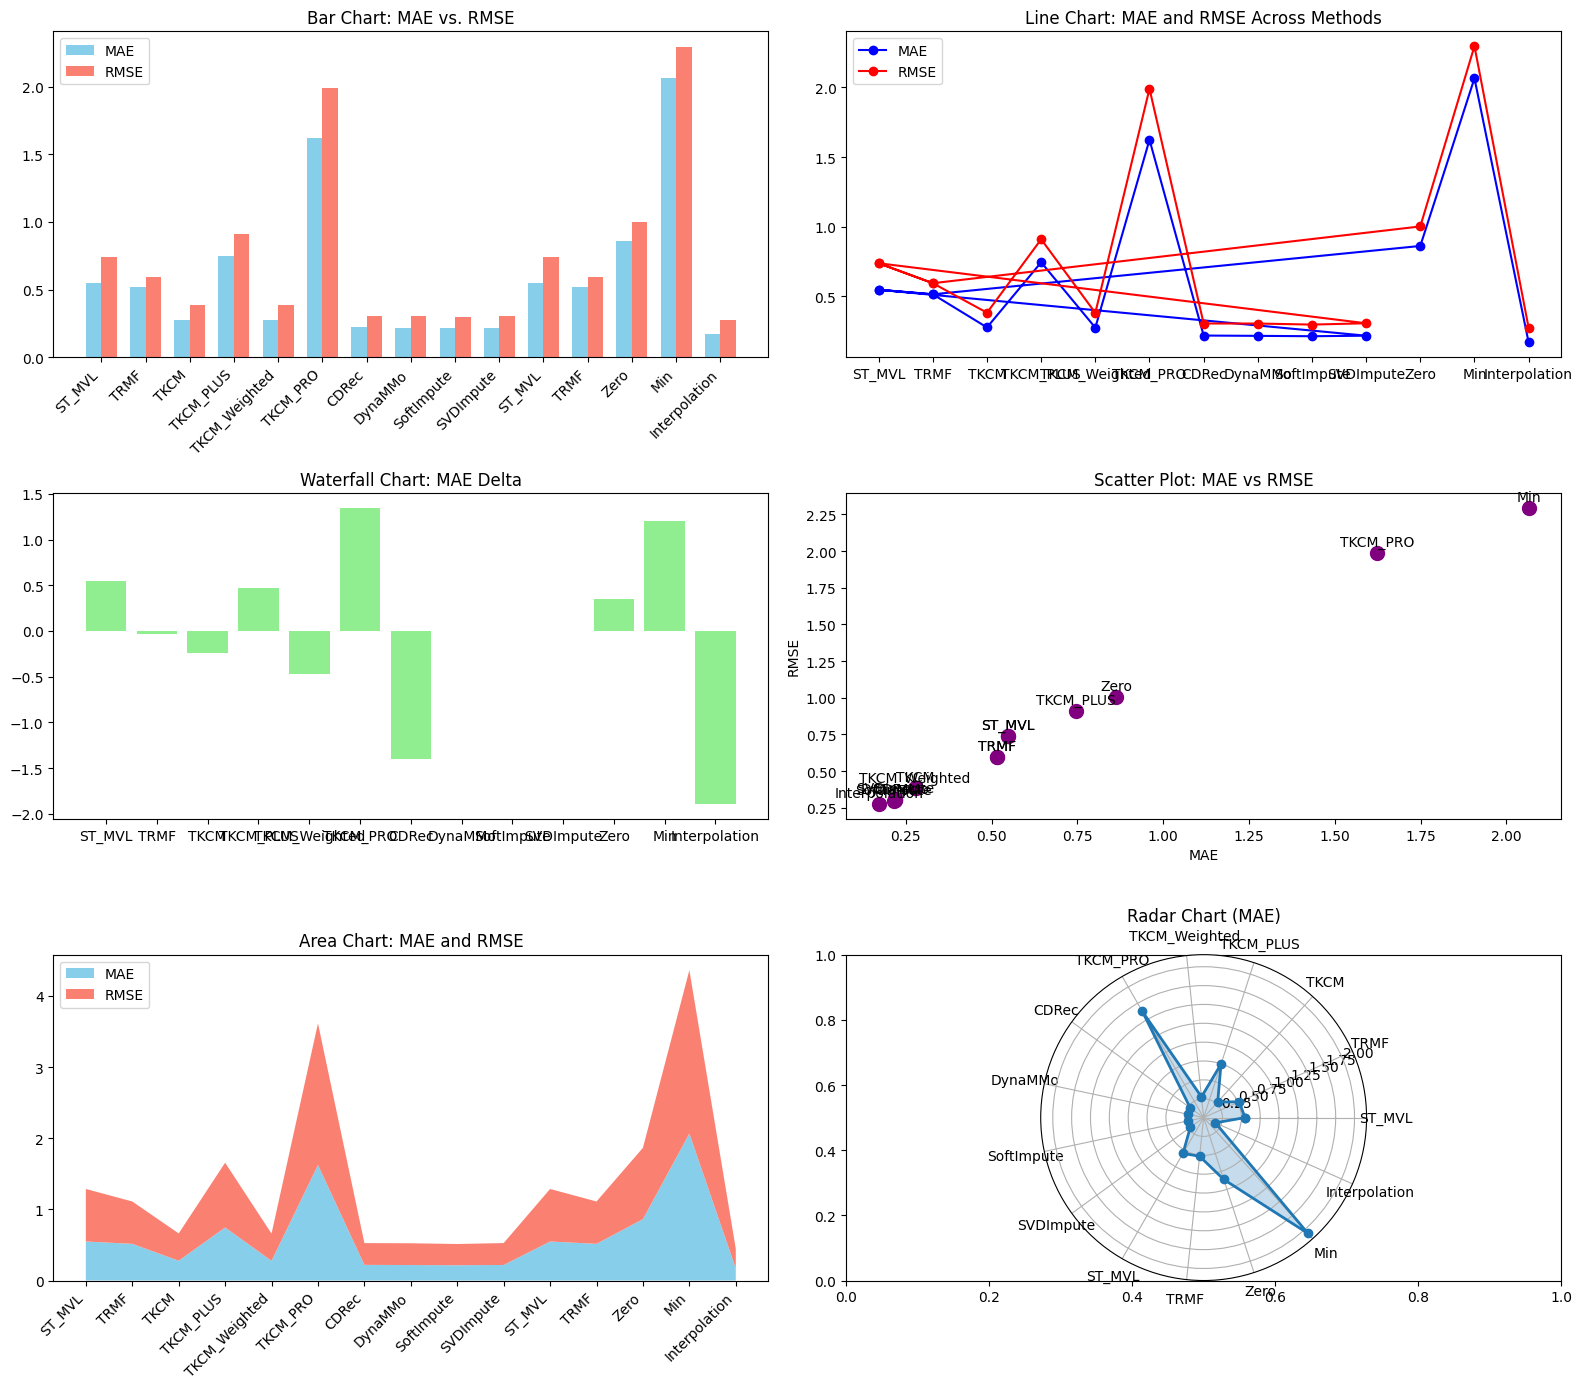

In [62]:
# -----------------------------------------------
# 🔹 STEP 23 (UPDATED): Comparison Chart — MAE vs. RMSE + Extras
# -----------------------------------------------

# Clean and extract
plot_df = results_df.copy()
methods = plot_df["Method"]
mae_scores = plot_df["MAE"]
rmse_scores = plot_df["RMSE"]

x = np.arange(len(methods))  # X-axis positions
width = 0.35

fig, axs = plt.subplots(3, 2, figsize=(16, 14))
axs = axs.flatten()

# --- Bar Chart ---
axs[0].bar(x - width/2, mae_scores, width, label="MAE", color="skyblue")
axs[0].bar(x + width/2, rmse_scores, width, label="RMSE", color="salmon")
axs[0].set_title("Bar Chart: MAE vs. RMSE")
axs[0].set_xticks(x)
axs[0].set_xticklabels(methods, rotation=45, ha="right")
axs[0].legend()

# --- Line Chart ---
axs[1].plot(methods, mae_scores, marker='o', label="MAE", color="blue")
axs[1].plot(methods, rmse_scores, marker='o', label="RMSE", color="red")
axs[1].set_title("Line Chart: MAE and RMSE Across Methods")
axs[1].legend()

# --- Waterfall Chart ---
waterfall_vals = [mae_scores[0]] + [mae_scores[i] - mae_scores[i - 1] for i in range(1, len(mae_scores))]
axs[2].bar(methods, waterfall_vals, color="lightgreen")
axs[2].set_title("Waterfall Chart: MAE Delta")

# --- Scatter Plot ---
axs[3].scatter(mae_scores, rmse_scores, c='purple', s=100)
for i, method in enumerate(methods):
    axs[3].annotate(method, (mae_scores[i], rmse_scores[i]), textcoords="offset points", xytext=(0,5), ha='center')
axs[3].set_xlabel("MAE")
axs[3].set_ylabel("RMSE")
axs[3].set_title("Scatter Plot: MAE vs RMSE")

# --- Area Chart ---
axs[4].stackplot(x, mae_scores, rmse_scores, labels=["MAE", "RMSE"], colors=["skyblue", "salmon"])
axs[4].set_xticks(x)
axs[4].set_xticklabels(methods, rotation=45, ha="right")
axs[4].legend()
axs[4].set_title("Area Chart: MAE and RMSE")

# --- Radar Chart (simulated using polar plot) ---
angles = np.linspace(0, 2 * np.pi, len(methods), endpoint=False).tolist()
scores = mae_scores.tolist()
scores += scores[:1]  # loop
angles += angles[:1]

axs[5] = plt.subplot(3, 2, 6, polar=True)
axs[5].plot(angles, scores, 'o-', linewidth=2)
axs[5].fill(angles, scores, alpha=0.25)
axs[5].set_title("Radar Chart (MAE)")
axs[5].set_xticks(angles[:-1])
axs[5].set_xticklabels(methods)

plt.tight_layout()
plt.show()

